# Causal Discovery on Deep Learning Outputs (UTRs and CDS)

Unlike the segmentation approaches, this notebook explores the causal relationships between entire functional regions of the cDNA sequences, specifically the **5' and 3' Untranslated Regions (UTRs)** and the **Coding Sequence (CDS)**. 

Each of these three regions is passed separately through the RNN. Studies in the report noted that utilizing the UTRs produced noticeably more consistent inter-and intra-algorithmic results, often identifying UTRs as highly influential factors on top of the causal order for the target predictions.

In [14]:
import io

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from causallearn.utils.GraphUtils import GraphUtils


In [ ]:
filepath = '../data/processed/rnn_hidden_states_pooled.csv'

In [25]:
all_columns = ['utr5','cds','utr3','y_pred','y','len','tissue']

all_rnn_data = pd.read_csv(filepath, names=all_columns)
all_rnn_data

,utr5,cds,utr3,y_pred,y,len,tissue
0.23858,-0.03204,-0.12674,0.13457,0.58075,1.0,1935.0,20.0
-0.44640,0.18358,0.13677,-0.09148,0.35752,1.0,4320.0,10.0
0.17260,-0.19898,-0.22365,-0.06009,0.56335,1.0,1719.0,22.0
0.18007,-0.15868,-0.08679,0.11612,0.56016,0.0,765.0,7.0
0.12154,-0.12210,0.00373,0.17049,0.60807,1.0,4593.0,7.0
...,...,...,...,...,...,...,...
0.42271,-0.13956,-0.13820,-0.21124,0.40931,1.0,1074.0,27.0
0.37526,-0.10260,-0.00290,-0.32103,0.31688,0.0,9525.0,27.0
0.25110,0.01716,0.05445,-0.03515,0.47825,1.0,1095.0,23.0
0.33399,-0.02515,-0.00321,-0.31321,0.28183,0.0,2625.0,12.0


In [ ]:
columns = ['utr5', 'cds', 'utr3', 'y_pred', 'tissue']
rnn_data = all_rnn_data[columns]
rnn_data


,utr5,cds,utr3,y,tissue
0,0.01390,-0.04713,0.01361,1.0,27.0
1,0.03924,-0.04226,0.03798,1.0,12.0
2,0.01957,-0.04420,0.02193,0.0,4.0
3,0.04274,-0.06324,0.04217,1.0,3.0
4,0.00194,-0.04211,0.00517,1.0,13.0
...,...,...,...,...,...
19643,0.03018,0.06034,0.02977,1.0,11.0
19644,0.03905,-0.04203,0.03823,1.0,12.0
19645,0.00570,-0.04172,0.00668,1.0,13.0
19646,0.00677,-0.04307,0.00545,1.0,13.0


---
# LiNGAM

LiNGAM (Linear Non-Gaussian Acyclic Model) assumes data linearity, non-Gaussian noise, acyclicity, and no latent common causes. 

We test both:
- **Direct LiNGAM**: Solves variables immediately using parameters.
- **ICA LiNGAM**: The Independent Component Analysis variant is extremely consistent in this biological modeling domain. For UTRs (5' and 3' regions) vs CDSs, ICA LiNGAM prominently places the UTR segments identically at the top of the causal cascade, indicating they strongly induce the model's PTR predictions compared to just utilizing central CDS components.

### Direct LiNGAM

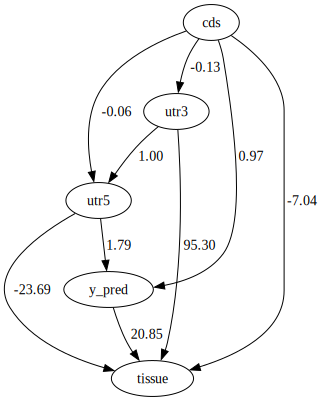

In [22]:
import lingam
from lingam.utils import make_dot,print_causal_directions, print_dagc, make_dot

model = lingam.DirectLiNGAM()
model.fit(rnn_data)

make_dot(model.adjacency_matrix_, labels=columns)

### ICA LINGAM

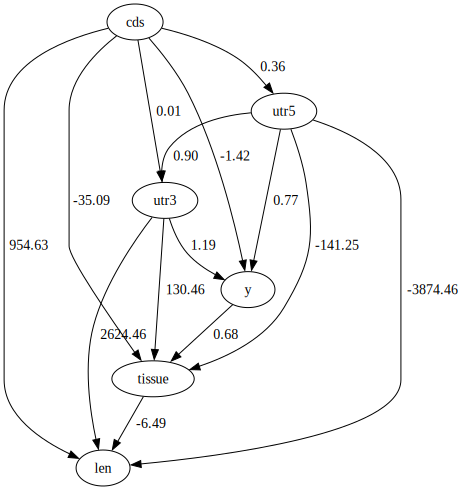

In [10]:
from causallearn.search.FCMBased import lingam
model = lingam.ICALiNGAM(max_iter=1000)
model.fit(rnn_data)

make_dot(model.adjacency_matrix_, labels=columns)

---
# GES

GES (Greedy Equivalence Search) uses distribution score evaluation to navigate graph spaces. Notably, while GES showed severe intra-algorithmic inconsistency internally across CDS subsections, when analyzing holistic UTR vs CDS groupings, the outputs stabilize.

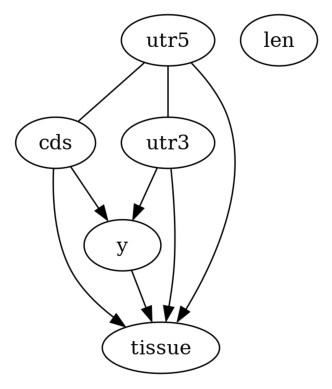

In [11]:
from causallearn.search.ScoreBased.GES import ges
from causallearn.score.LocalScoreFunction import local_score_cv_general

Record = ges(rnn_data)

pyd = GraphUtils.to_pydot(Record['G'], labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')

plt.axis('off')
plt.imshow(img)

---
# FCI 

Fast Causal Inference (FCI) handles causal detection via conditional independence. As applied to functional cDNA regions, the framework infers undirected connectivity but lacks definitive mapping to target parameters.

In [67]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz

graph, edges = fci(rnn_data.to_numpy(), independence_test_method=fisherz, depth=3)

Depth=0, working on node 5: 100%|██████████| 6/6 [00:00<00:00, 502.12it/s]

X4 --> X6


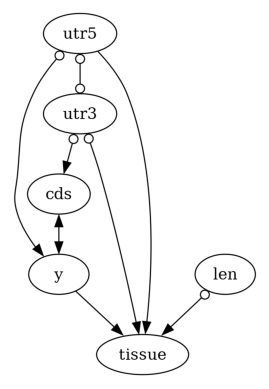

In [68]:
pyd = GraphUtils.to_pydot(graph, labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)


---
# CGNN

Causal Generative Neural Networks (CGNN) typically required an initial directed acyclic graph structure supplied before iterating properly on this dataset, rendering it less standalone.

In [ ]:
import networkx as nx
from cdt.causality.graph import CGNN

obj = CGNN()
output = obj.predict(rnn_data[:100])   
nx.draw_networkx(output, font_size=8, with_labels=True)

"\nimport networkx as nx\nfrom cdt.causality.graph import CGNN\n\nobj = CGNN()\noutput = obj.predict(rnn_data[:100])   \nnx.draw_networkx(output, font_size=8, with_labels=True)'\n"

---
# PC

The Peter-Clark (PC) algorithm proved too burdensome, often taking several GPU hours across larger sequence evaluations, leading to its deprioritization.

In [ ]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

cg = pc(rnn_data.to_numpy(), 0.05, fisherz)
pyd = GraphUtils.to_pydot(cg.G, labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)